# Week 9 Jupyter Notebook — Gradient Boosting  
## Integrated Capstone Project: Wisconsin and Coimbra Breast Cancer Datasets

**Week topic:** Gradient boosting, learning rate, number of estimators, tree depth, and regularization

### Notebook purpose

For Week 9, I am applying **gradient boosting classification** to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset**  
   This dataset uses tumor image-based measurements such as radius, texture, perimeter, area, smoothness, concavity, and symmetry.

2. **Breast Cancer Coimbra dataset**  
   This dataset uses clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I am not merging the two datasets because they do not contain the same patients or the same variables. Instead, I am using the same modeling approach on each dataset and comparing the results.

For this week, I focus on:

- Gradient boosting classification
- Learning rate
- Number of estimators
- Tree depth
- Regularization through shrinkage, shallow trees, subsampling, and minimum samples per leaf
- Hyperparameter tuning with cross-validation
- Feature importance and model interpretation

Since both datasets have binary outcomes, this is a classification task. For Wisconsin, the positive class is malignant diagnosis. For Coimbra, the positive class is breast cancer patient.


## 1. Import libraries

I am importing the libraries needed to load the datasets, train gradient boosting models, tune hyperparameters, and evaluate classification performance.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 2. Why gradient boosting is useful for this project

Gradient boosting builds an ensemble of many small decision trees. Each new tree tries to correct the mistakes made by the earlier trees. This can create a strong predictive model because the model learns gradually.

For this breast cancer project, gradient boosting is useful because:

- It can capture nonlinear relationships.
- It can capture interactions between features.
- It can work well with tabular healthcare data.
- It provides feature importance scores.

The main risk is overfitting. If the model uses too many trees, trees that are too deep, or a learning rate that is too aggressive, it may memorize the training data instead of generalizing.


## 3. Evaluation helper function

I use the same evaluation function for both datasets.

The metrics are:

- Accuracy
- Precision for the positive class
- Recall for the positive class
- F1-score
- ROC-AUC

For this project, recall is especially important because missing a cancer case would be a serious concern.


In [ ]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_positive": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_positive": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_positive": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_pred, test_pred, train_prob, test_prob


# Part A: Breast Cancer Wisconsin Diagnostic Dataset

## 4. Load and prepare Wisconsin dataset

The sklearn version of this dataset originally uses:

- `0 = malignant`
- `1 = benign`

For consistency with my project, I create:

- `diagnosis_malignant = 1` for malignant tumors
- `diagnosis_malignant = 0` for benign tumors


In [ ]:
cancer = load_breast_cancer()

wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")

wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Wisconsin dataset shape:", wisconsin_df.shape)
print("\nDiagnosis counts:")
print(wisconsin_df["diagnosis_label"].value_counts())

print("\nDiagnosis percentages:")
print(wisconsin_df["diagnosis_label"].value_counts(normalize=True).round(3))

wisconsin_df.head()


Wisconsin dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Diagnosis percentages:
diagnosis_label
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


## 5. Wisconsin features and target

The Wisconsin dataset has 30 tumor morphology features. These are direct measurements from tumor images.


In [ ]:
wisconsin_target = "diagnosis_malignant"
wisconsin_label = "diagnosis_label"

wisconsin_features = [
    col for col in wisconsin_df.columns
    if col not in [wisconsin_target, wisconsin_label]
]

X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df[wisconsin_target]

print("Number of Wisconsin rows:", X_w.shape[0])
print("Number of Wisconsin features:", X_w.shape[1])


Number of Wisconsin rows: 569
Number of Wisconsin features: 30


## 6. Wisconsin EDA before gradient boosting

Gradient boosting can model complex relationships, but I still want to understand the data first. I check which tumor features are most correlated with malignant diagnosis.


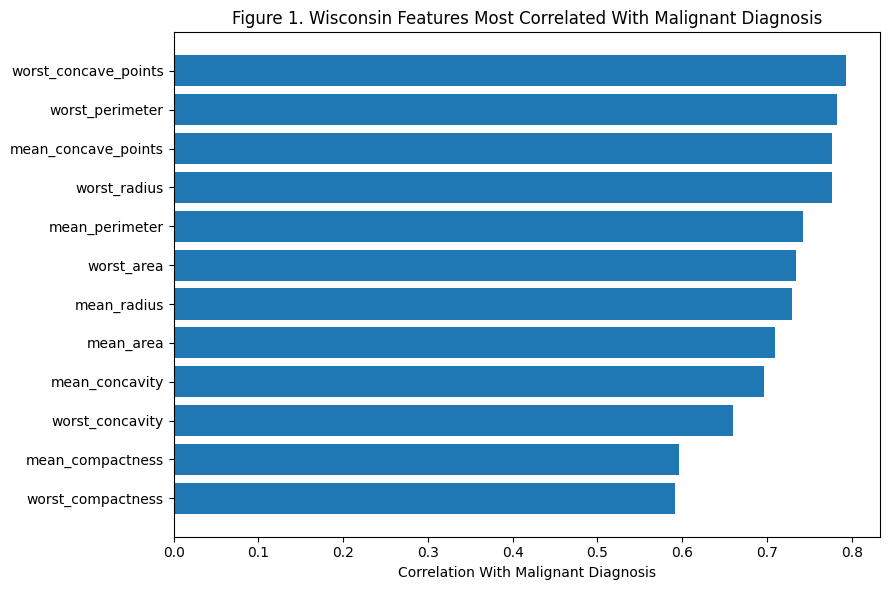

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [ ]:
corr_with_target_w = wisconsin_df[wisconsin_features + [wisconsin_target]].corr()[wisconsin_target].drop(wisconsin_target)
top_corr_w = corr_with_target_w.abs().sort_values(ascending=False).head(12)
top_corr_w_signed = corr_with_target_w.loc[top_corr_w.index].sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr_w_signed.index, top_corr_w_signed.values)
plt.xlabel("Correlation With Malignant Diagnosis")
plt.title("Figure 1. Wisconsin Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": top_corr_w_signed.index,
    "correlation_with_malignant": top_corr_w_signed.values
})


### Wisconsin EDA note

From earlier weeks, I expected tumor size and shape-related variables to matter. Gradient boosting should be useful because it can combine these features in nonlinear ways and capture interactions without me manually creating interaction terms.


## 7. Wisconsin train-test split

I use a stratified split so that benign and malignant cases stay in similar proportions in the training and testing sets.


In [ ]:
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w,
    y_w,
    test_size=0.20,
    random_state=42,
    stratify=y_w
)

print("Training shape:", X_train_w.shape)
print("Testing shape:", X_test_w.shape)

print("\nTraining target distribution:")
print(y_train_w.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_w.value_counts(normalize=True).round(3))


Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626
1    0.374
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.632
1    0.368
Name: proportion, dtype: float64


## 8. Wisconsin baseline gradient boosting model

I start with a baseline gradient boosting classifier. This gives me a simple comparison point before tuning the learning rate, number of estimators, tree depth, and regularization settings.


In [ ]:
wisconsin_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

w_gb_base_results, w_gb_base_train_pred, w_gb_base_test_pred, w_gb_base_train_prob, w_gb_base_test_prob = evaluate_classifier(
    "Wisconsin Baseline Gradient Boosting",
    wisconsin_gb_baseline,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_gb_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.994709


### Baseline model note

If the training accuracy is much higher than the testing accuracy, that may suggest overfitting. Gradient boosting can overfit if the trees become too complex or if too many trees are added.


## 9. Wisconsin learning rate and number of estimators

The learning rate controls how much each new tree contributes to the model.

- Smaller learning rate: slower learning, usually needs more trees
- Larger learning rate: faster learning, but may overfit faster

The number of estimators controls how many trees are added.

I test several learning rate and estimator combinations to see the tradeoff.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

w_lr_rows = []

for learning_rate in [0.01, 0.05, 0.10, 0.20]:
    for n_estimators in [50, 100, 200, 300]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42
        )

        recall_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="roc_auc")

        w_lr_rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

w_lr_results_df = pd.DataFrame(w_lr_rows).sort_values(["CV_recall_mean", "CV_roc_auc_mean"], ascending=[False, False])
w_lr_results_df.head(10)


,learning_rate,n_estimators,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
10,0.10,200,0.958824,0.014409,0.993189,0.005366
13,0.20,100,0.952941,0.014409,0.992570,0.005668
7,0.05,300,0.952941,0.014409,0.992157,0.005346
14,0.20,200,0.947059,0.022010,0.993602,0.005447
15,0.20,300,0.947059,0.022010,0.993602,0.006084
11,0.10,300,0.947059,0.022010,0.993498,0.005437
12,0.20,50,0.947059,0.022010,0.990506,0.005705
6,0.05,200,0.941176,0.026307,0.991331,0.005532
9,0.10,100,0.941176,0.026307,0.990918,0.006014
5,0.05,100,0.935294,0.034300,0.989577,0.005832


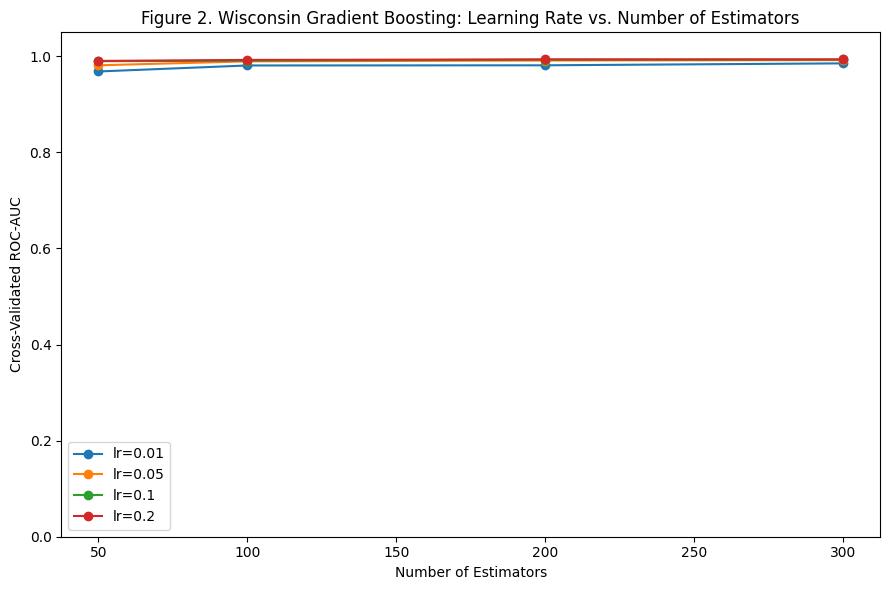

In [ ]:
# Figure 2: Wisconsin learning rate and number of estimators
plt.figure(figsize=(9, 6))

for learning_rate in sorted(w_lr_results_df["learning_rate"].unique()):
    plot_df = w_lr_results_df[w_lr_results_df["learning_rate"] == learning_rate].sort_values("n_estimators")
    plt.plot(plot_df["n_estimators"], plot_df["CV_roc_auc_mean"], marker="o", label=f"lr={learning_rate}")

plt.xlabel("Number of Estimators")
plt.ylabel("Cross-Validated ROC-AUC")
plt.title("Figure 2. Wisconsin Gradient Boosting: Learning Rate vs. Number of Estimators")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Wisconsin tree depth comparison

Tree depth controls how complex each individual tree can become.

- Shallow trees are more regularized and less likely to overfit.
- Deeper trees can capture more interactions but may overfit.

Gradient boosting often works well with shallow trees because the model builds many simple trees in sequence.


In [ ]:
w_depth_rows = []

for max_depth in [1, 2, 3, 4, 5]:
    model = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=max_depth,
        random_state=42
    )

    recall_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="roc_auc")

    w_depth_rows.append({
        "max_depth": max_depth,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std()
    })

w_depth_results_df = pd.DataFrame(w_depth_rows).sort_values("CV_roc_auc_mean", ascending=False)
w_depth_results_df


,max_depth,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,2,0.941176,0.026307,0.991331,0.005532
2,3,0.947059,0.034300,0.990712,0.006336
0,1,0.929412,0.044019,0.990093,0.007278
3,4,0.923529,0.054551,0.983901,0.010552
4,5,0.923529,0.057635,0.955366,0.046820


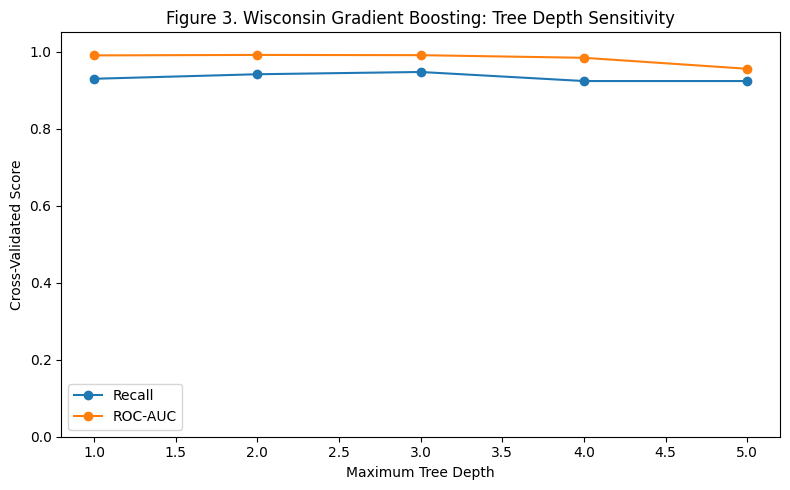

In [ ]:
# Figure 3: Wisconsin tree depth comparison
plot_df = w_depth_results_df.sort_values("max_depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["max_depth"], plot_df["CV_recall_mean"], marker="o", label="Recall")
plt.plot(plot_df["max_depth"], plot_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Cross-Validated Score")
plt.title("Figure 3. Wisconsin Gradient Boosting: Tree Depth Sensitivity")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Wisconsin tuned gradient boosting model

Now I tune several gradient boosting hyperparameters together.

I tune:

- `learning_rate`: how much each tree contributes
- `n_estimators`: number of trees
- `max_depth`: tree complexity
- `min_samples_leaf`: minimum samples in each leaf
- `subsample`: fraction of samples used for each tree

`subsample` below 1.0 adds randomness and can act like regularization because each tree is trained on only part of the data.


In [ ]:
gb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.10],
    "n_estimators": [100, 200, 300],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

wisconsin_gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=1
)

wisconsin_gb_grid.fit(X_train_w, y_train_w)

print("Best Wisconsin gradient boosting parameters:")
print(wisconsin_gb_grid.best_params_)
print("\nBest cross-validated recall:", wisconsin_gb_grid.best_score_)

w_gb_tuned_results, w_gb_tuned_train_pred, w_gb_tuned_test_pred, w_gb_tuned_train_prob, w_gb_tuned_test_prob = evaluate_classifier(
    "Wisconsin Tuned Gradient Boosting",
    wisconsin_gb_grid.best_estimator_,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_gb_base_results, w_gb_tuned_results])


Best Wisconsin gradient boosting parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 1.0}

Best cross-validated recall: 0.9647058823529411


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.994709
1,Wisconsin Tuned Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.995370


## 12. Wisconsin model evaluation

I evaluate the tuned Wisconsin gradient boosting model using a classification report, confusion matrix, and ROC curve.


Wisconsin tuned gradient boosting classification report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



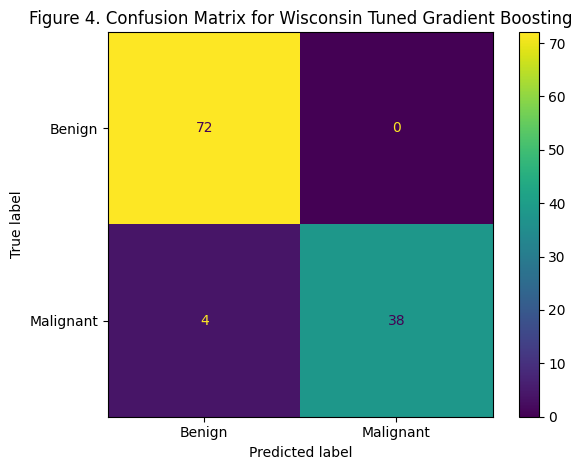

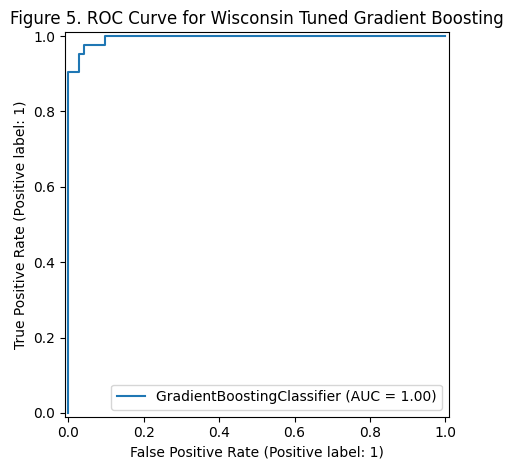

In [ ]:
print("Wisconsin tuned gradient boosting classification report:")
print(classification_report(y_test_w, w_gb_tuned_test_pred, target_names=["Benign", "Malignant"]))

cm_w = confusion_matrix(y_test_w, w_gb_tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Figure 4. Confusion Matrix for Wisconsin Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(wisconsin_gb_grid.best_estimator_, X_test_w, y_test_w)
plt.title("Figure 5. ROC Curve for Wisconsin Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


## 13. Wisconsin feature importance

Gradient boosting provides feature importance scores. These show which tumor measurements were most useful in the boosted tree model.


In [ ]:
w_gb_feature_importance = pd.DataFrame({
    "feature": wisconsin_features,
    "importance": wisconsin_gb_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

w_gb_feature_importance.head(15)


,feature,importance
22,worst_perimeter,0.509790
7,mean_concave_points,0.161250
27,worst_concave_points,0.090442
20,worst_radius,0.063799
21,worst_texture,0.031344
23,worst_area,0.030426
1,mean_texture,0.029962
26,worst_concavity,0.019804
3,mean_area,0.014064
13,area_error,0.013311


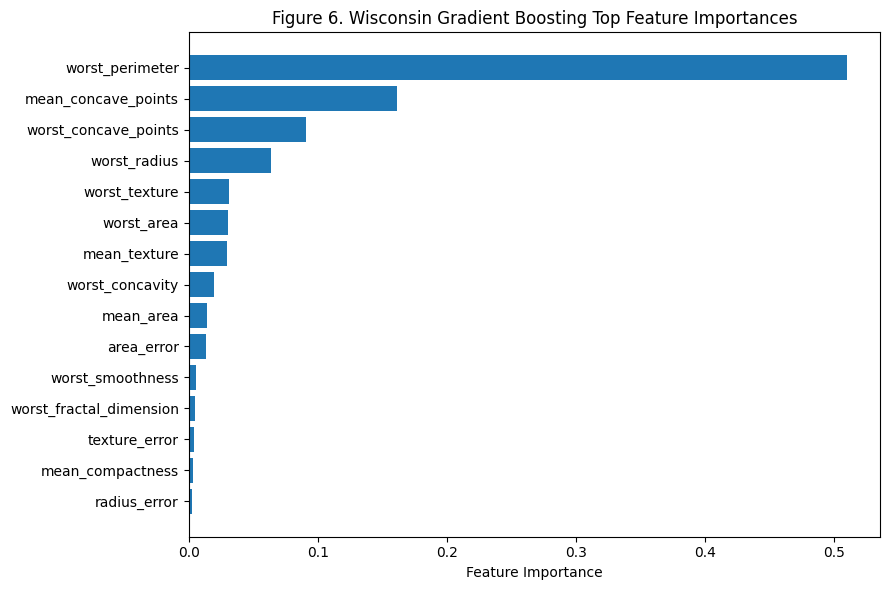

In [ ]:
# Figure 6: Wisconsin gradient boosting feature importance
plot_df = w_gb_feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 6. Wisconsin Gradient Boosting Top Feature Importances")
plt.tight_layout()
plt.show()


### Wisconsin gradient boosting interpretation

For the Wisconsin dataset, I expected gradient boosting to perform well because the dataset has strong tumor morphology features. The model can combine size, shape, and texture features in a nonlinear way.

If the top features are related to radius, area, perimeter, concavity, or worst-case measurements, that supports my earlier conclusion that tumor size and shape are major signals for diagnosis.


# Part B: Breast Cancer Coimbra Dataset

## 14. Load and prepare Coimbra dataset

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with the rest of my project, I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls


In [ ]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nClass percentages:")
print(coimbra_df["diagnosis_group"].value_counts(normalize=True).round(3))

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 15. Coimbra features and target

The Coimbra dataset has 9 predictors. These are clinical and blood-based biomarkers rather than tumor image measurements.


In [ ]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_c = coimbra_df[coimbra_features]
y_c = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of Coimbra rows:", X_c.shape[0])
print("Number of Coimbra features:", X_c.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of Coimbra rows: 116
Number of Coimbra features: 9


## 16. Coimbra EDA before gradient boosting

Before modeling, I check how the biomarkers differ between patients and healthy controls.


In [ ]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


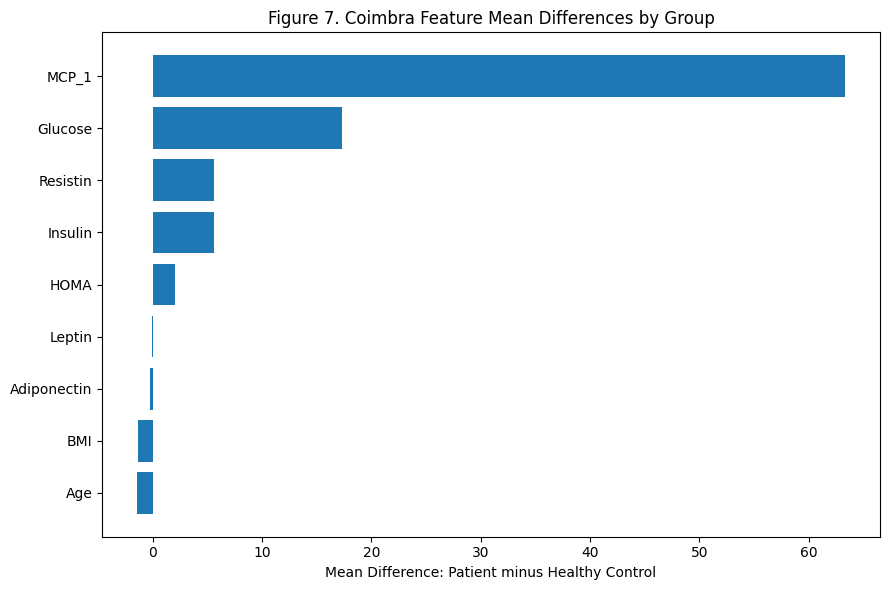

In [ ]:
# Figure 7: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure 7. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


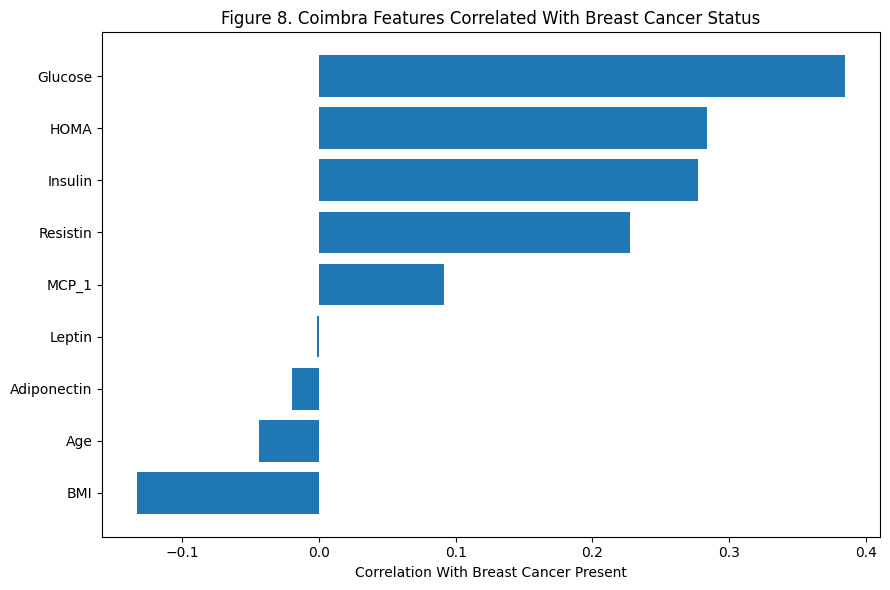

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [ ]:
# Figure 8: Coimbra correlations with breast cancer status
corr_with_target_c = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
corr_with_target_c_sorted = corr_with_target_c.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(corr_with_target_c_sorted.index, corr_with_target_c_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure 8. Coimbra Features Correlated With Breast Cancer Status")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": corr_with_target_c_sorted.index,
    "correlation_with_breast_cancer_present": corr_with_target_c_sorted.values
})


### Coimbra EDA note

The Coimbra predictors are more indirect than the Wisconsin tumor measurements. Because of this, I expect prediction to be harder and less stable. Gradient boosting may still help because it can model nonlinear relationships among biomarkers.


## 17. Coimbra train-test split

I use a stratified split so the training and testing sets keep similar proportions of patients and healthy controls.


In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


## 18. Coimbra baseline gradient boosting model

I start with a baseline gradient boosting model for Coimbra.


In [ ]:
coimbra_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

c_gb_base_results, c_gb_base_train_pred, c_gb_base_test_pred, c_gb_base_train_prob, c_gb_base_test_prob = evaluate_classifier(
    "Coimbra Baseline Gradient Boosting",
    coimbra_gb_baseline,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_gb_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119


## 19. Coimbra learning rate and number of estimators

Since Coimbra is small, I expect the learning rate and number of estimators to matter a lot. Too many trees or too high of a learning rate may overfit.


In [ ]:
c_lr_rows = []

for learning_rate in [0.01, 0.05, 0.10, 0.20]:
    for n_estimators in [50, 100, 200, 300]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42
        )

        recall_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="roc_auc")

        c_lr_rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

c_lr_results_df = pd.DataFrame(c_lr_rows).sort_values(["CV_recall_mean", "CV_roc_auc_mean"], ascending=[False, False])
c_lr_results_df.head(10)


,learning_rate,n_estimators,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,0.01,100,0.741818,0.137822,0.739987,0.079229
4,0.05,50,0.723636,0.173881,0.773321,0.100441
12,0.20,50,0.723636,0.161971,0.755126,0.097857
6,0.05,200,0.723636,0.161971,0.743687,0.093357
7,0.05,300,0.721818,0.215099,0.743687,0.093357
5,0.05,100,0.705455,0.155303,0.748308,0.100460
8,0.10,50,0.705455,0.155303,0.745429,0.109983
15,0.20,300,0.705455,0.110086,0.729091,0.081630
2,0.01,200,0.703636,0.157417,0.770316,0.113371
3,0.01,300,0.703636,0.157417,0.769343,0.112646


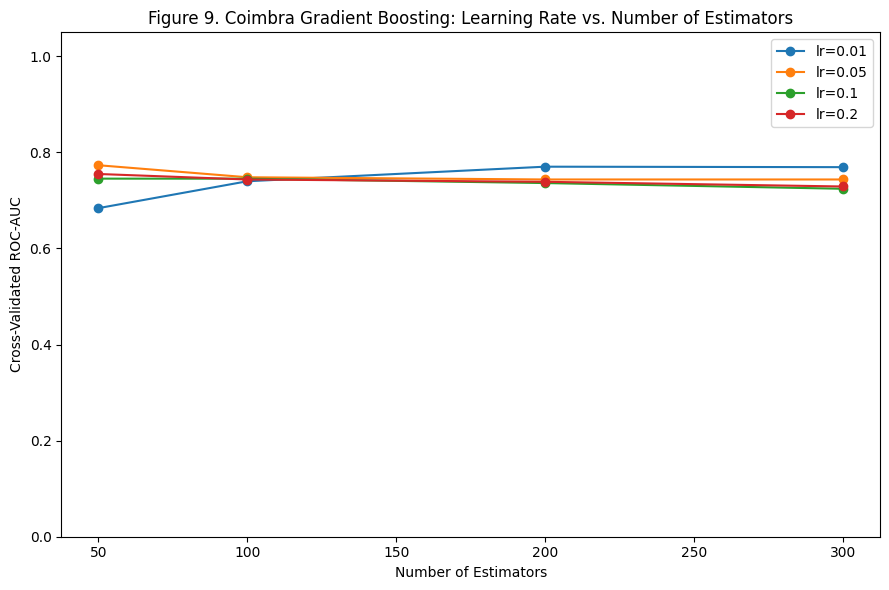

In [ ]:
# Figure 9: Coimbra learning rate and number of estimators
plt.figure(figsize=(9, 6))

for learning_rate in sorted(c_lr_results_df["learning_rate"].unique()):
    plot_df = c_lr_results_df[c_lr_results_df["learning_rate"] == learning_rate].sort_values("n_estimators")
    plt.plot(plot_df["n_estimators"], plot_df["CV_roc_auc_mean"], marker="o", label=f"lr={learning_rate}")

plt.xlabel("Number of Estimators")
plt.ylabel("Cross-Validated ROC-AUC")
plt.title("Figure 9. Coimbra Gradient Boosting: Learning Rate vs. Number of Estimators")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 20. Coimbra tree depth comparison

For Coimbra, I expect shallow trees to be safer because the dataset is small. Deep trees may overfit to a few observations.


In [ ]:
c_depth_rows = []

for max_depth in [1, 2, 3, 4, 5]:
    model = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=max_depth,
        random_state=42
    )

    recall_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="roc_auc")

    c_depth_rows.append({
        "max_depth": max_depth,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std()
    })

c_depth_results_df = pd.DataFrame(c_depth_rows).sort_values("CV_roc_auc_mean", ascending=False)
c_depth_results_df


,max_depth,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
3,4,0.801818,0.091525,0.753043,0.115401
4,5,0.823636,0.074212,0.747778,0.089446
2,3,0.721818,0.195621,0.745354,0.089301
1,2,0.723636,0.161971,0.743687,0.093357
0,1,0.685455,0.148112,0.724684,0.108992


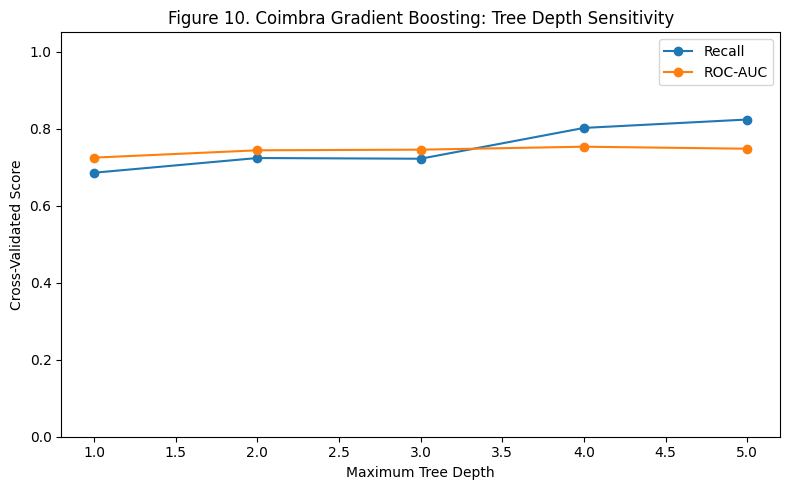

In [ ]:
# Figure 10: Coimbra tree depth comparison
plot_df = c_depth_results_df.sort_values("max_depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["max_depth"], plot_df["CV_recall_mean"], marker="o", label="Recall")
plt.plot(plot_df["max_depth"], plot_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Cross-Validated Score")
plt.title("Figure 10. Coimbra Gradient Boosting: Tree Depth Sensitivity")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 21. Coimbra tuned gradient boosting model

Now I tune the same main gradient boosting hyperparameters for Coimbra. Because this dataset is small, I pay close attention to regularization settings like `max_depth`, `min_samples_leaf`, and `subsample`.


In [ ]:
coimbra_gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=1
)

coimbra_gb_grid.fit(X_train_c, y_train_c)

print("Best Coimbra gradient boosting parameters:")
print(coimbra_gb_grid.best_params_)
print("\nBest cross-validated recall:", coimbra_gb_grid.best_score_)

c_gb_tuned_results, c_gb_tuned_train_pred, c_gb_tuned_test_pred, c_gb_tuned_train_prob, c_gb_tuned_test_prob = evaluate_classifier(
    "Coimbra Tuned Gradient Boosting",
    coimbra_gb_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_gb_base_results, c_gb_tuned_results])


Best Coimbra gradient boosting parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 1.0}

Best cross-validated recall: 0.82


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119
1,Coimbra Tuned Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.874126


## 22. Coimbra model evaluation

I evaluate the tuned Coimbra gradient boosting model using a classification report, confusion matrix, and ROC curve.


Coimbra tuned gradient boosting classification report:
                 precision    recall  f1-score   support

Healthy Control       0.82      0.82      0.82        11
        Patient       0.85      0.85      0.85        13

       accuracy                           0.83        24
      macro avg       0.83      0.83      0.83        24
   weighted avg       0.83      0.83      0.83        24



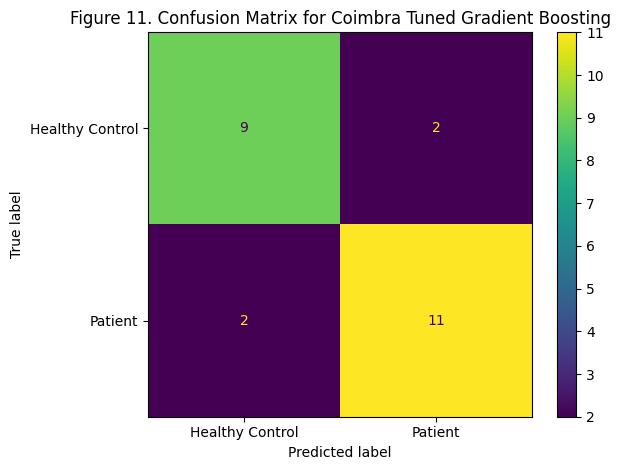

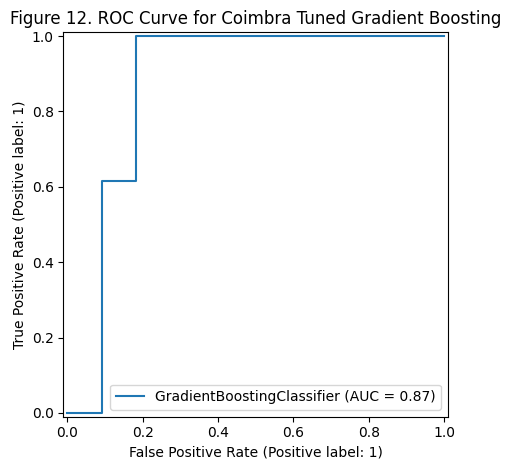

In [ ]:
print("Coimbra tuned gradient boosting classification report:")
print(classification_report(y_test_c, c_gb_tuned_test_pred, target_names=["Healthy Control", "Patient"]))

cm_c = confusion_matrix(y_test_c, c_gb_tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["Healthy Control", "Patient"]
)

disp.plot()
plt.title("Figure 11. Confusion Matrix for Coimbra Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(coimbra_gb_grid.best_estimator_, X_test_c, y_test_c)
plt.title("Figure 12. ROC Curve for Coimbra Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


## 23. Coimbra feature importance

I use feature importance to see which clinical biomarkers were most useful in the boosted tree model.


In [ ]:
c_gb_feature_importance = pd.DataFrame({
    "feature": coimbra_features,
    "importance": coimbra_gb_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

c_gb_feature_importance


,feature,importance
2,Glucose,0.330695
1,BMI,0.217956
7,Resistin,0.150324
0,Age,0.097080
5,Leptin,0.050135
8,MCP_1,0.049969
4,HOMA,0.036681
6,Adiponectin,0.033798
3,Insulin,0.033362


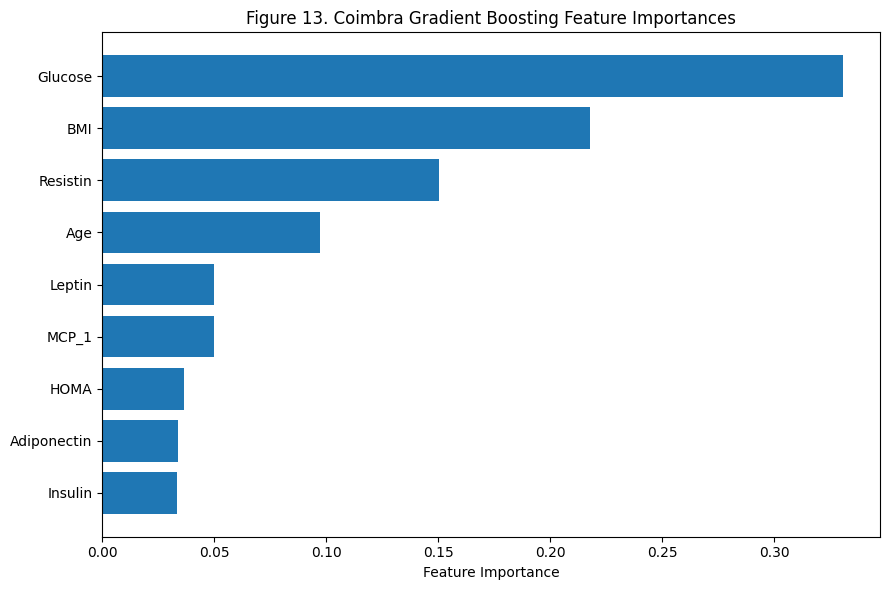

In [ ]:
# Figure 13: Coimbra gradient boosting feature importance
plot_df = c_gb_feature_importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 13. Coimbra Gradient Boosting Feature Importances")
plt.tight_layout()
plt.show()


### Coimbra gradient boosting interpretation

For Coimbra, I expected gradient boosting to be more sensitive to overfitting because the dataset is smaller. The model may still be useful because it can capture nonlinear relationships among biomarkers.

Feature importance helps connect the model back to the healthcare context by showing which clinical or blood-based variables contributed most to prediction.


# Part C: Week 9 Comparison Across Both Datasets

## 24. Compare Wisconsin and Coimbra gradient boosting results

Now I compare the baseline and tuned gradient boosting models across both datasets.


In [ ]:
wisconsin_gb_results_df = pd.DataFrame([
    w_gb_base_results,
    w_gb_tuned_results
])
wisconsin_gb_results_df["dataset"] = "Wisconsin"

coimbra_gb_results_df = pd.DataFrame([
    c_gb_base_results,
    c_gb_tuned_results
])
coimbra_gb_results_df["dataset"] = "Coimbra"

week9_combined_results = pd.concat(
    [wisconsin_gb_results_df, coimbra_gb_results_df],
    ignore_index=True
)

week9_combined_results.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc,dataset
1,Wisconsin Tuned Gradient Boosting,1.0,0.964912,1.000000,0.904762,0.950000,0.995370,Wisconsin
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.000000,0.904762,0.950000,0.994709,Wisconsin
2,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119,Coimbra
3,Coimbra Tuned Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.874126,Coimbra


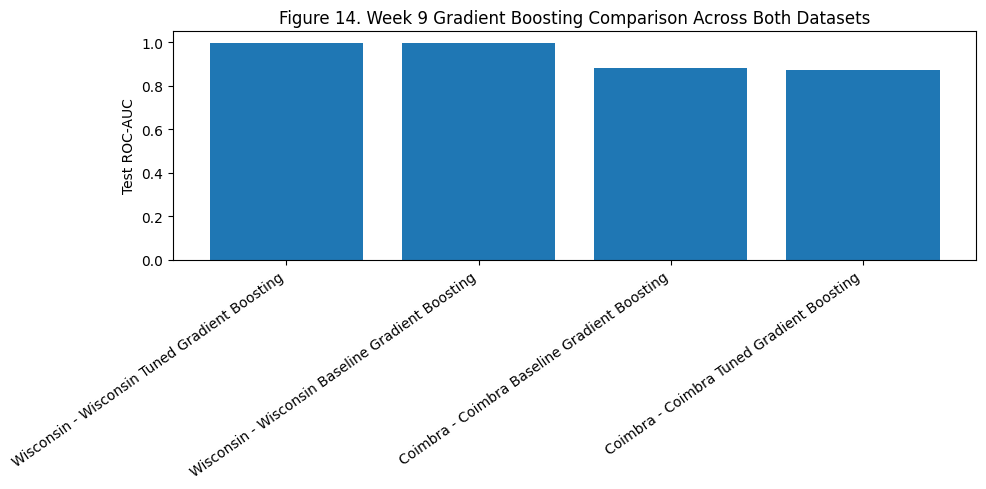

In [ ]:
# Figure 14: Combined gradient boosting comparison
plot_df = week9_combined_results.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["dataset"] + " - " + plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure 14. Week 9 Gradient Boosting Comparison Across Both Datasets")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 25. Regularization comparison

In this notebook, I treated regularization as more than one setting. For gradient boosting, regularization came from:

- Lower learning rate
- Limiting tree depth
- Increasing `min_samples_leaf`
- Using `subsample` below 1.0
- Using cross-validation to avoid choosing a model that only works on one split

This matters because boosted trees can become very powerful and can overfit if they are allowed to become too complex.


## 26. Week 9 summary

This cell prints a short summary using the actual notebook results.


In [ ]:
best_w_gb = wisconsin_gb_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_gb = coimbra_gb_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

print("Week 9 Gradient Boosting Summary")


print("Best Wisconsin gradient boosting model:")
print(best_w_gb["model"])
print(f"Test accuracy: {best_w_gb['test_accuracy']:.4f}")
print(f"Test recall for malignant cases: {best_w_gb['test_recall_positive']:.4f}")
print(f"Test precision for malignant cases: {best_w_gb['test_precision_positive']:.4f}")
print(f"Test F1: {best_w_gb['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_w_gb['test_roc_auc']:.4f}")

print("\nBest Coimbra gradient boosting model:")
print(best_c_gb["model"])
print(f"Test accuracy: {best_c_gb['test_accuracy']:.4f}")
print(f"Test recall for patients: {best_c_gb['test_recall_positive']:.4f}")
print(f"Test precision for patients: {best_c_gb['test_precision_positive']:.4f}")
print(f"Test F1: {best_c_gb['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_c_gb['test_roc_auc']:.4f}")

print("\nBest Wisconsin gradient boosting hyperparameters:")
print(wisconsin_gb_grid.best_params_)

print("\nBest Coimbra gradient boosting hyperparameters:")
print(coimbra_gb_grid.best_params_)

print("\nTop 5 Wisconsin feature importances:")
for feature in w_gb_feature_importance.head(5)["feature"]:
    print("-", feature)

print("\nTop 5 Coimbra feature importances:")
for feature in c_gb_feature_importance.head(5)["feature"]:
    print("-", feature)


Week 9 Gradient Boosting Summary
Best Wisconsin gradient boosting model:
Wisconsin Tuned Gradient Boosting
Test accuracy: 0.9649
Test recall for malignant cases: 0.9048
Test precision for malignant cases: 1.0000
Test F1: 0.9500
Test ROC-AUC: 0.9954

Best Coimbra gradient boosting model:
Coimbra Baseline Gradient Boosting
Test accuracy: 0.8333
Test recall for patients: 0.8462
Test precision for patients: 0.8462
Test F1: 0.8462
Test ROC-AUC: 0.8811

Best Wisconsin gradient boosting hyperparameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 1.0}

Best Coimbra gradient boosting hyperparameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 1.0}

Top 5 Wisconsin feature importances:
- worst_perimeter
- mean_concave_points
- worst_concave_points
- worst_radius
- worst_texture

Top 5 Coimbra feature importances:
- Glucose
- BMI
- Resistin
- Age
- Leptin


## 27. Week 9 findings and interpretation

After running this Week 9 notebook, I learned that gradient boosting is a strong modeling technique because it builds a sequence of trees that correct earlier mistakes. This makes it more flexible than a single decision tree.

For the **Wisconsin dataset**, I expected gradient boosting to perform well because the tumor measurements directly describe the tumor. The model can use combinations of radius, area, concavity, and other shape features to classify malignant and benign tumors.

For the **Coimbra dataset**, I expected the model to be less stable because the dataset is smaller and the predictors are indirect clinical biomarkers. Gradient boosting can still be useful, but it needs more careful regularization.

The most important hyperparameters were learning rate, number of estimators, and tree depth. A lower learning rate makes the model learn more slowly, usually requiring more trees. More estimators can improve performance, but too many trees may overfit. Tree depth controls how complex each tree can become. Shallow trees are usually safer because each tree only captures a simple pattern.

Regularization was important in both datasets. I used smaller learning rates, limited tree depth, minimum leaf size, subsampling, and cross-validation. These techniques helped reduce the risk that the model would memorize the training data.

Overall, gradient boosting gave me another way to compare image-based tumor features with clinical biomarker data. It also helped me see how tuning and regularization can affect a powerful ensemble model.


## 28. Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is likely better suited for gradient boosting because it has more rows and direct tumor morphology features. The Coimbra dataset is still useful, but it asks a different question: can routine clinical and blood-based biomarkers help identify breast cancer status?

This comparison is helpful for my capstone because it shows that model performance depends not only on the algorithm, but also on the type and quality of the data. Tumor image features appear more directly related to diagnosis, while clinical biomarkers may provide useful but less direct information.


## 29. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Gradient Tree Boosting*. https://scikit-learn.org/stable/modules/ensemble.html#gradient-tree-boosting

Scikit-learn developers. (n.d.). *GradientBoostingClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html


